# 4. Drift association test

In this notebook we link gene expression changes along one differentiation lineage to the
differentiation rate (the drift term $\|v\|$) inferred by *pseudodynamics+*. The workflow follows
[tradeSeq](https://www.nature.com/articles/s41467-020-14766-3): one generalized additive model (GAM)
per gene along pseudotime, then a Wald test on the fitted trend. Here the test is restricted to the
pseudotime window in which the drift changes fastest, so that the significant genes are those that
change expression where the cells accelerate or decelerate their differentiation.

Steps:

1. load the trained model and predict $g$, $v$, $D$ for every cell (as in tutorial 3)
2. assign lineage branches with [Palantir](https://github.com/dpeerlab/Palantir) when the dataset carries no branch information
3. project the drift onto the lineage pseudotime and find the window where it changes fastest
4. fit a GAM per gene along the lineage pseudotime
5. run the association test inside that window
6. rank the significant genes by how well their trend tracks the derivative of the drift
7. visualize gene trends against the drift

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
if sys.platform.startswith("darwin"):
    os.environ['KMP_DUPLICATE_LIB_OK']='True'

# Palantir's nearest-neighbour search segfaults with a multi-threaded OpenBLAS (observed on macOS).
# Limiting the numerical libraries to one thread avoids it. The expensive step of this notebook,
# the per-gene GAM fitting, is parallelised across processes and is not affected.
for var in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS']:
    os.environ[var] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import palantir
sc.settings.set_figure_params(frameon=False, dpi=30)

import pseudodynamics as pdp
from pseudodynamics import de_test
os.chdir(pdp.main_dir)
print("workding directory changed to:", pdp.main_dir)

workding directory changed to: /Users/weizhongzheng/Documents/python_project/pseudodynamics_plus


## Experimental config, model and data

We reuse the `tom_pos` experiment from tutorial 3. Intermediate results (Palantir output and imputed
expression) are cached under `results/` so that the notebook can be re-run quickly.

In [2]:
tompos_config_path = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/V4_config.json"
tompos_config = pdp.ExperimentConfig(config=tompos_config_path)

pde_model = pdp.models.pde_params.load_from_checkpoint(
                    checkpoint_path = tompos_config.find_lastest_ckpt(),
                    map_location='cpu')

result_dir = "results/tom_pos_drift_association"
pdp.tl.make_dir(result_dir)

In [3]:
data_name = tompos_config.experiment_config['dataset']
adata = sc.read_h5ad(f"data/{data_name}.h5ad")

timepoints = adata.uns['pop']['t']
print("observed time points (days):", timepoints)
adata

observed time points (days): [  3   7  12  27  49  76 112 161 269]


AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

## Predict the dynamic parameters

`predict_param` returns the growth rate $g$, the differentiation velocity $v$ and the diffusion $D$ for
every cell at every observed time point. We store the growth rate and the norm of the velocity in
`adata.obsm` as `cells x timepoints` matrices, because the lineage analysis below subsets cells.

In [4]:
ds_config = tompos_config.dataset_config.copy()
ds_config['timepoint_idx'] = None
DS_full = pdp.reader.TwoTimpepoint_AnnDS(AnnData=adata, split=None, **ds_config)

g_pred_ay, v_pred_ay, D_pred_ay = pde_model.predict_param(DS_full)
v_norm = np.sqrt(np.sum(v_pred_ay**2, axis=-1))           # (n_timepoints, n_cells)

adata.obsm['g'] = g_pred_ay.T                              # (n_cells, n_timepoints)
adata.obsm['v_norm'] = v_norm.T
print('growth rate :', adata.obsm['g'].shape, '| drift norm :', adata.obsm['v_norm'].shape)


Dataset : Computing density :
	 `density_funs` not specified, default estimator gaussian kde


Dataset : all cells are used


growth rate : (49390, 9) | drift norm : (49390, 9)


## Assign lineage branches

The association test needs the cells of **one** lineage ordered by pseudotime. This dataset carries a
diffusion pseudotime (`obs['dpt_pseudotime']`) but no branch assignment, so we compute one with
Palantir. If your `AnnData` already has `obsm['branch_masks']` and `obs['palantir_pseudotime']`
(for example from a previous Palantir run, or a lineage assignment from
[CellRank](https://cellrank.readthedocs.io) converted to boolean masks), this section is skipped.

Palantir needs:

- a **root cell**: here the earliest cell (smallest diffusion pseudotime) among the day-7 cells
- **terminal cells**: for each mature cell type, the cell with the largest diffusion pseudotime;
  progenitor annotations (`HSC`, `Int prog`) and the one-cell `Eos` group are excluded
- the **multiscale diffusion space**, computed from the diffusion map already stored in `adata`

In [5]:
palantir_cache = os.path.join(result_dir, 'palantir')
cached = all(os.path.exists(os.path.join(palantir_cache, f)) for f in ['obs.csv', 'fate_probabilities.csv', 'branch_masks.csv'])

if 'branch_masks' in adata.obsm and 'palantir_pseudotime' in adata.obs:
    print("branch information found in adata, nothing to do")

elif cached:
    print("loading cached Palantir results from", palantir_cache)
    obs = pd.read_csv(os.path.join(palantir_cache, 'obs.csv'), index_col=0).loc[adata.obs_names]
    adata.obs['palantir_pseudotime'] = obs['palantir_pseudotime'].values
    adata.obs['palantir_entropy'] = obs['palantir_entropy'].values
    adata.obsm['palantir_fate_probabilities'] = pd.read_csv(os.path.join(palantir_cache, 'fate_probabilities.csv'), index_col=0).loc[adata.obs_names]
    adata.obsm['branch_masks'] = pd.read_csv(os.path.join(palantir_cache, 'branch_masks.csv'), index_col=0).loc[adata.obs_names].astype(bool)

else:
    # terminal cells: the most advanced cell of each mature cell type
    terminal_cells = adata.obs[['anno_man', 'dpt_pseudotime']].sort_values('dpt_pseudotime', ascending=False)
    terminal_cells = terminal_cells.drop_duplicates('anno_man', keep='first')
    terminal_cells = terminal_cells[~terminal_cells['anno_man'].isin(['Int prog', 'HSC', 'Eos'])]
    terminal_states = terminal_cells['anno_man'].astype(str)          # index: cell barcode, value: lineage name
    print("terminal cells:\n", terminal_states)

    # root cell: the earliest day-7 cell
    root_cell = adata.obs.query("`timepoint_tx_days` == 7")['dpt_pseudotime'].idxmin()

    # multiscale space from the stored diffusion map, then Palantir
    palantir.utils.determine_multiscale_space(adata)                 # -> obsm['DM_EigenVectors_multiscaled']
    pr_res = palantir.core.run_palantir(adata, root_cell, knn=30, num_waypoints=500,
                                        terminal_states=terminal_states)
    palantir.presults.select_branch_cells(adata, q=.001, eps=.02)     # -> obsm['branch_masks']

    # cache
    pdp.tl.make_dir(palantir_cache)
    adata.obs[['palantir_pseudotime', 'palantir_entropy']].to_csv(os.path.join(palantir_cache, 'obs.csv'))
    adata.obsm['palantir_fate_probabilities'].to_csv(os.path.join(palantir_cache, 'fate_probabilities.csv'))
    adata.obsm['branch_masks'].to_csv(os.path.join(palantir_cache, 'branch_masks.csv'))

branch_masks = adata.obsm['branch_masks']
print("cells per branch:\n", branch_masks.sum())

loading cached Palantir results from results/tom_pos_drift_association/palantir
cells per branch:
 Bas/MC prog     10626
Mono/DC prog    14157
Neu             23442
Ly              13275
Meg              4657
Ery              8162
dtype: int64


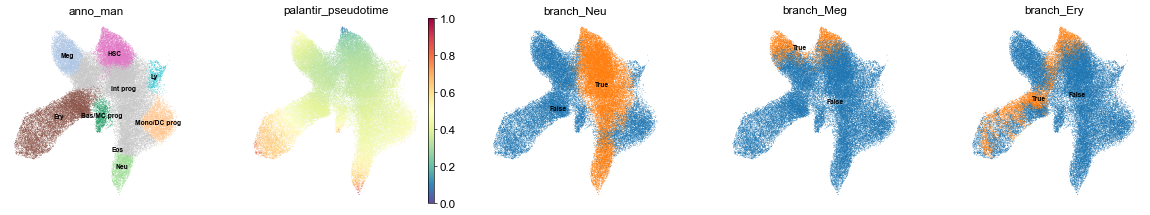

In [6]:
lineages = ['Neu', 'Meg', 'Ery']
for lineage in lineages:
    adata.obs[f'branch_{lineage}'] = branch_masks[lineage].values.astype(str)

sc.pl.umap(adata, color=['anno_man', 'palantir_pseudotime'] + [f'branch_{l}' for l in lineages],
           ncols=5, legend_loc='on data', legend_fontsize=8)

## Project the drift onto the lineage pseudotime

For each lineage we take its branch cells and average the drift norm $\|v\|$ (and the growth rate) in
100 pseudotime bins, separately for every observed time point. `project_params_to_pseudotime` returns
one smoothed curve per time point, evaluated at the bin centres `x_project`.

In [7]:
adata_lin, x_project, v_project, g_project = {}, {}, {}, {}

for lineage in lineages:
    ad = adata[branch_masks[lineage].values].copy()
    pdt_max = ad.obs['palantir_pseudotime'].max()

    x = np.linspace(0, pdt_max, 100)
    x_project[lineage] = (x[1:] + x[:-1]) / 2                      # bin centres, length 99

    v_project[lineage] = pdp.tl.project_params_to_pseudotime(ad, ad.obsm['v_norm'].T, param_names='v',
                                    timepoints=None, pseudotime_key='palantir_pseudotime', nbins=100, return_y=True)
    g_project[lineage] = pdp.tl.project_params_to_pseudotime(ad, ad.obsm['g'].T, param_names='g',
                                    timepoints=None, pseudotime_key='palantir_pseudotime', nbins=100, return_y=True)
    adata_lin[lineage] = ad
    print(f"{lineage}: {ad.n_obs} cells, pseudotime max {pdt_max:.3f}")

/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:386: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdata = data.groupby("pseudotime_bin").agg({y_col:"mean"}).reset_index()
/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:389: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  gdata[y_col] = gdata[y_col].fillna(method='bfill').fillna(method='ffill')
/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:386: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

Neu: 23442 cells, pseudotime max 0.921


/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:386: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdata = data.groupby("pseudotime_bin").agg({y_col:"mean"}).reset_index()
/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:389: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  gdata[y_col] = gdata[y_col].fillna(method='bfill').fillna(method='ffill')
/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:386: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

Meg: 4657 cells, pseudotime max 0.542


Ery: 8162 cells, pseudotime max 0.667


/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:386: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdata = data.groupby("pseudotime_bin").agg({y_col:"mean"}).reset_index()
/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:389: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  gdata[y_col] = gdata[y_col].fillna(method='bfill').fillna(method='ffill')
/Users/weizhongzheng/Documents/python_project/pseudodynamics_plus/src/pseudodynamics/functions/eval_funs.py:386: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

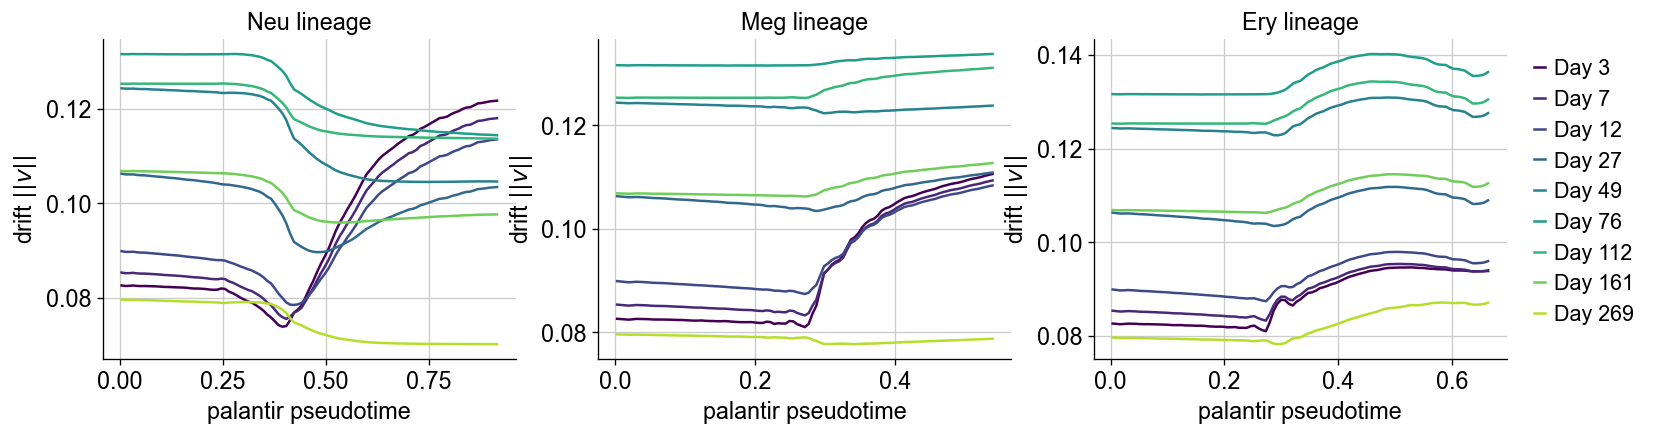

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.5), dpi=60)
for ax, lineage in zip(axs, lineages):
    for i, t in enumerate(timepoints):
        ax.plot(x_project[lineage], v_project[lineage][i], label=f'Day {t}', color=plt.cm.viridis(i / len(timepoints)))
    ax.set_title(f'{lineage} lineage')
    ax.set_xlabel('palantir pseudotime')
    ax.set_ylabel(r'drift $||v||$')
axs[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.show()

## Find the pseudotime window where the drift changes fastest

We slide a window of `min_bins` consecutive bins along the drift curve and keep the window with the
largest mean absolute slope. The association test below is restricted to this window. You can also
set `pseudotime_range` by hand, for example from the plot above.

In [9]:
def find_steepest_region(x_values, rate_values, min_bins=30):
    '''
    Identify the pseudotime window with the steepest slope of a rate curve.

    x_values    : 1-D array, pseudotime bin centres
    rate_values : 1-D array, rate (e.g. drift norm) at those bins
    min_bins    : window width in bins

    Returns: dict with start_bin, end_bin, mean_slope, window_idx
    '''
    dx = np.diff(x_values)[0]                       # uniform spacing
    slopes = np.gradient(rate_values, dx)
    mean_abs_slopes = np.array([np.mean(np.abs(slopes[i:i + min_bins]))
                                for i in range(len(slopes) - min_bins + 1)])
    max_idx = int(np.argmax(mean_abs_slopes))
    return {'start_bin': x_values[max_idx],
            'end_bin': x_values[max_idx + min_bins - 1],
            'mean_slope': mean_abs_slopes[max_idx],
            'window_idx': (max_idx, max_idx + min_bins)}

Meg lineage, Day 161: fastest change of drift in pseudotime 0.277 - 0.435


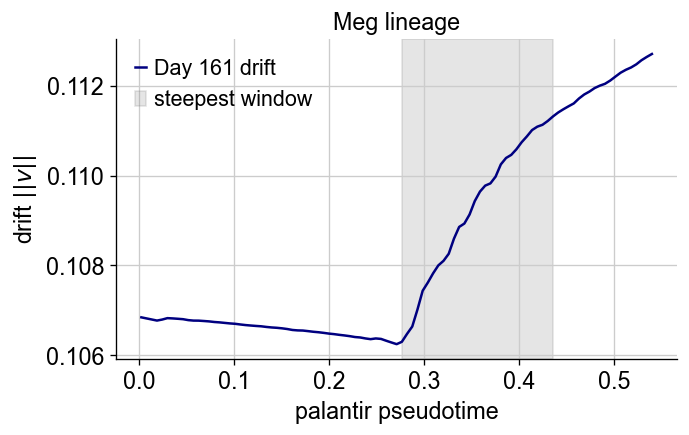

In [10]:
lineage = 'Meg'
day = 161
day_idx = int(np.where(timepoints == day)[0][0])

steepest_region = find_steepest_region(x_project[lineage], v_project[lineage][day_idx], min_bins=30)
pseudotime_range = (steepest_region['start_bin'], steepest_region['end_bin'])
print(f"{lineage} lineage, Day {day}: fastest change of drift in pseudotime {pseudotime_range[0]:.3f} - {pseudotime_range[1]:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=60)
ax.plot(x_project[lineage], v_project[lineage][day_idx], color='navy', label=f'Day {day} drift')
ax.axvspan(*pseudotime_range, alpha=0.2, color='gray', label='steepest window')
ax.set_xlabel('palantir pseudotime'); ax.set_ylabel(r'drift $||v||$'); ax.set_title(f'{lineage} lineage')
ax.legend(frameon=False)
plt.show()

## Fit gene trends along the lineage pseudotime

Following the original analysis, the GAMs are fitted on MAGIC-imputed expression of all 22,035 genes
in `adata.raw`. MAGIC is run on the lineage cells only, with the stored diffusion similarity restricted
to those cells and re-normalized.

`run_fitGAM_parallel` fits one negative-binomial GAM per gene (`statsmodels`) across `n_cores`
processes; here `n_cores = os.cpu_count() - 1` uses every CPU core of the machine but one, which keeps
the machine responsive. Each worker receives only its own genes, and only the coefficients, their
covariance and the fitted trend of every gene are kept, so memory stays low. Genes with constant
expression in the lineage (here: genes not expressed in these cells) are skipped, and their entry in
`gam_fit['models']` has `model = None`.

**Time required:** on the MacBook used to build this tutorial (11 CPU cores, 10 workers) MAGIC
imputation took about 10 seconds and fitting the 22,035 genes took about 45 seconds.

The fitted object can be written to disk with `de_test.save_gamfit(gam_fit, save_dir)` and read back
with `de_test.load_gamfit(save_dir)`. Note that this stores the full `statsmodels` result of every
gene, which is several GB for a lineage of this size.

In [11]:
from sklearn.preprocessing import normalize

ad = adata_lin[lineage]
cell_idx = np.where(adata.obs_names.isin(ad.obs_names))[0]

# log-normalized expression of all genes, from adata.raw
X_lin = adata.raw.X[cell_idx]
genes = adata.raw.var_names.values

imputed_path = os.path.join(result_dir, f'{lineage}_MAGIC_imputed_{len(genes)}genes.npy')
if os.path.exists(imputed_path):
    X_imputed = np.load(imputed_path)
else:
    T_lin = normalize(adata.obsp['DM_Similarity'][cell_idx][:, cell_idx], norm='l1', axis=1)   # re-normalize rows
    X_imputed = palantir.utils.run_magic_imputation(X_lin, dm_res={'T': T_lin}, n_steps=3, sparse=False)
    X_imputed = np.asarray(X_imputed, dtype=np.float32)
    np.save(imputed_path, X_imputed)

expression_matrix = X_imputed                                  # cells x genes
cell_time = ad.obs['palantir_pseudotime'].values
print('expression matrix:', expression_matrix.shape)

expression matrix: (4657, 22035)


In [12]:
gam_fit = de_test.run_fitGAM_parallel(expression_matrix, cell_time, genes, n_knots=7, n_cores=max(1, os.cpu_count() - 1))

n_fitted = sum(m['model'] is not None for m in gam_fit['models'].values())
print(f"GAM fitted for {n_fitted} / {len(gam_fit['models'])} genes")

GAM fitted for 17744 / 22035 genes


## Association test inside the steepest window

`AssociationTest.association_test` performs, for every gene, a Wald test of whether the fitted trend is
flat across `n_points` contrast points placed inside `restrcited_pseudotime`. The result table contains
the Wald statistic, its degrees of freedom, the p-value and the mean log fold change between the
contrast points.

In [13]:
test = de_test.AssociationTest(gam_fit, [lineage])
result = test.association_test(restrcited_pseudotime=list(pseudotime_range))
result['gene_symbol'] = gam_fit['gene_symbol']
result.head()

,gene,waldStat,df,pvalue,meanLogFC,gene_symbol
0,0,NaN,NaN,NaN,NaN,Gm37381
1,1,NaN,NaN,NaN,NaN,Rp1
2,2,NaN,NaN,NaN,NaN,Sox17
3,3,0.088926,1.0,7.655472e-01,3.499333,Gm37323
4,4,26.438338,1.0,2.720861e-07,0.365271,Mrpl15


In [14]:
# significant genes after Benjamini-Hochberg correction
significant_genes = de_test.select_top_de_genes(result, qval_threshold=1e-2)

# annotate transcription factors (mouse TF list from the SCENIC resources)
tf_path = os.path.join(result_dir, 'allTFs_mm.txt')
if not os.path.exists(tf_path):
    import urllib.request
    urllib.request.urlretrieve('https://resources.aertslab.org/cistarget/tf_lists/allTFs_mm.txt', tf_path)
mmTF = pd.read_csv(tf_path, sep='\t', names=['gene_symbol'])

significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
significant_genes = significant_genes.set_index('gene_symbol')
print(f"{significant_genes.shape[0]} significant genes, of which {significant_genes['is_TF'].sum()} TFs")
significant_genes.head()

3930 significant genes, of which 361 TFs


,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF
gene_symbol,,,,,,,
Pf4,6575,1431.434807,1.0,0.000000e+00,2.274282,0.000000e+00,False
Rgs10,10165,658.477098,1.0,3.202783e-145,2.988241,2.841509e-141,False
Itga2b,15996,645.337920,1.0,2.306892e-142,1.807494,1.364450e-138,False
Plek,14826,624.916778,1.0,6.373567e-138,1.806939,2.827314e-134,False
Treml1,20582,558.023227,1.0,2.262742e-123,2.187347,8.030019e-120,False


## Rank genes by agreement with the drift derivative

A gene whose expression rises or falls exactly where the drift accelerates is a candidate regulator of
the transition. We evaluate each significant gene's fitted trend at the bin centres, scale it to
$[0, 1]$, and compare it with the derivative of the drift curve using the Pearson correlation and the
mutual information. Bins outside the pseudotime range covered by the lineage cells are dropped, because
the GAM only extrapolates there.

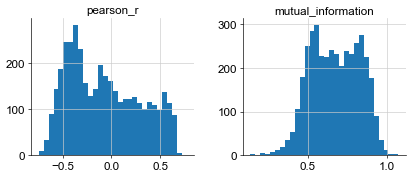

In [15]:
from scipy.stats import pearsonr

expr_df = de_test.prepare_expression_data(gam_fit, pseudotime=x_project[lineage])   # bins x genes, scaled to [0, 1]

dx = np.diff(x_project[lineage])[0]
drift_derivative = np.gradient(v_project[lineage][day_idx], dx)

valid = (x_project[lineage] >= cell_time.min()) & (x_project[lineage] <= cell_time.max())

sig = [g for g in significant_genes.index if g in expr_df.columns]
significant_genes = significant_genes.loc[sig]
significant_genes['pearson_r'] = [pearsonr(expr_df[g].values[valid], drift_derivative[valid])[0] for g in sig]
significant_genes['mutual_information'] = [de_test.calculate_mutual_information(expr_df[g].values[valid], drift_derivative[valid]) for g in sig]

significant_genes.to_csv(os.path.join(result_dir, f'{lineage}_Day{day}_sigDE.csv'))
significant_genes[['pearson_r', 'mutual_information']].hist(figsize=(8, 3), bins=30)
plt.show()

In [16]:
drift_genes = significant_genes.query("`meanLogFC` > 2 & `fdr` < 1e-3 & `pearson_r` > 0.1 & `mutual_information` > 0.4").sort_values('mutual_information', ascending=False)
drift_TFs = significant_genes.query("`meanLogFC` > 1 & `mutual_information` > 0.3 & `is_TF`").sort_values('mutual_information', ascending=False)

print(f"{drift_genes.shape[0]} drift-related genes, {drift_TFs.shape[0]} drift-related TFs")
drift_TFs.head(10)

27 drift-related genes, 104 drift-related TFs


,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Zfp521,20904,20.534992,1.0,5.855104e-06,1.162439,4.905239e-05,True,-0.449574,0.940109
Zfp467,7694,70.131724,1.0,5.547363e-17,3.817665,2.116826e-15,True,-0.608810,0.925439
Erg,19780,78.381704,1.0,8.493517e-19,1.456729,3.874267e-17,True,-0.553745,0.923314
Prnp,2441,28.503890,1.0,9.351041e-08,1.473284,1.112097e-06,True,-0.449611,0.922841
Cbx7,18729,27.157523,1.0,1.875340e-07,1.532303,2.103416e-06,True,-0.506041,0.915628
Hoxa5,7754,36.293543,1.0,1.697253e-09,1.579911,2.648729e-08,True,-0.466646,0.900733
Ikzf2,373,110.619094,1.0,7.170556e-26,1.395517,6.117036e-24,True,-0.593182,0.898902
Nkx2-3,21846,126.994462,1.0,1.862926e-29,2.729387,1.967605e-27,True,-0.644543,0.896055
Nfia,5213,63.647801,1.0,1.487750e-15,1.280750,4.943564e-14,True,-0.545632,0.893999


## Visualize gene trends against the drift

The scaled trends of the selected genes are drawn on the left axis, the drift norm at the chosen day on
the right axis, and the steepest window is shaded.

In [17]:
from itertools import cycle

def plot_gene_trends_with_drift(expr_df, rate_x, rate_y, window, rate_label='drift', ax=None):
    '''
    expr_df : DataFrame, index = pseudotime, columns = genes, scaled expression
    rate_x, rate_y : 1-D arrays, pseudotime and rate curve
    window : (start, end) pseudotime window to highlight
    '''
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    style_cycle = cycle([(c, ls) for ls in ['-', '--', '-.', ':'] for c in sns.color_palette()])

    for gene in expr_df.columns:
        color, ls = next(style_cycle)
        ax.plot(expr_df.index, expr_df[gene], color=color, linestyle=ls, alpha=0.8, label=gene)

    ax2 = ax.twinx()
    mask = (rate_x >= expr_df.index.min()) & (rate_x <= expr_df.index.max())
    ax2.plot(rate_x[mask], rate_y[mask], color='navy', linewidth=2.5, linestyle='--', label=rate_label)
    ax2.set_ylabel(rate_label, color='navy'); ax2.tick_params(axis='y', colors='navy')

    ax.axvspan(*window, alpha=0.2, color='gray')
    ax.set_xlabel('palantir pseudotime'); ax.set_ylabel('scaled expression')
    ax.grid(True, alpha=0.3)
    return ax, ax2

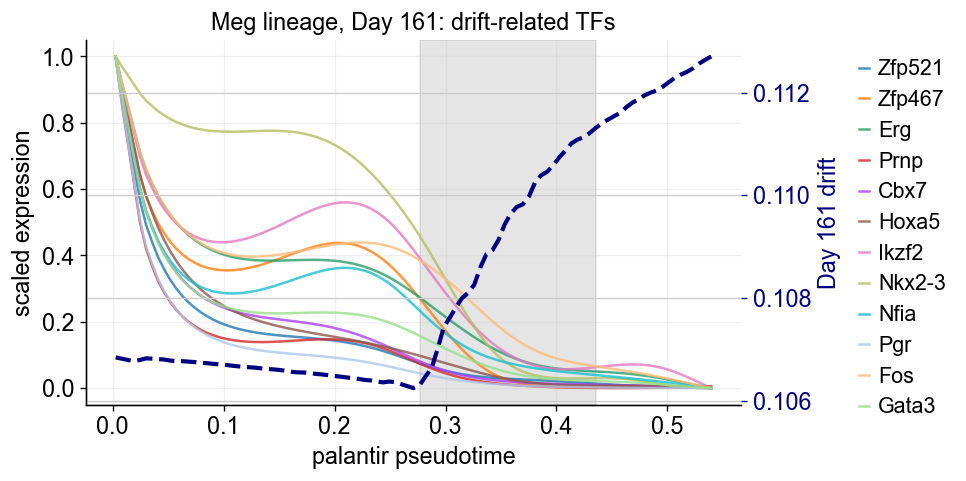

In [18]:
top_TFs = drift_TFs.index[:12].to_list()

fig, ax = plt.subplots(figsize=(7, 4), dpi=60)
ax, ax2 = plot_gene_trends_with_drift(expr_df.loc[valid, top_TFs], x_project[lineage], v_project[lineage][day_idx],
                                      pseudotime_range, rate_label=f'Day {day} drift', ax=ax)
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', ncol=1, frameon=False)
ax.set_title(f'{lineage} lineage, Day {day}: drift-related TFs')
plt.show()

The same genes as a heatmap, with the drift norm in the bottom row, makes the ordering of the
transcription factors along the transition easier to read.

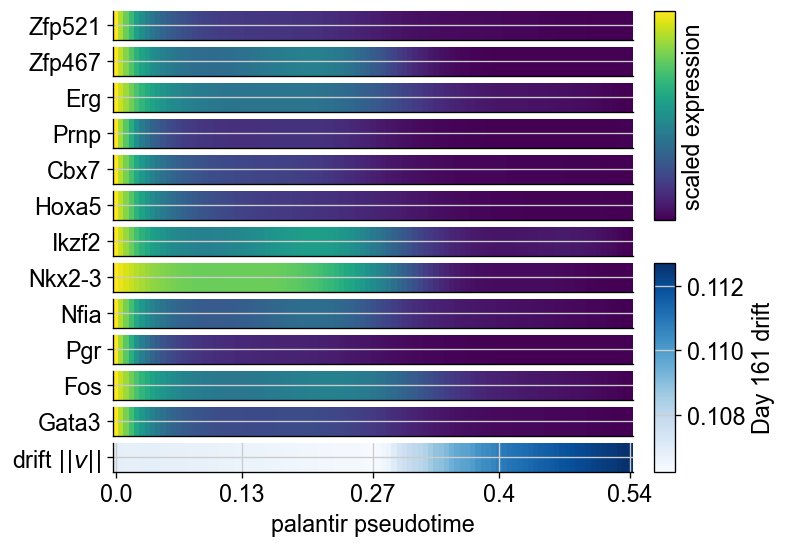

In [19]:
n = len(top_TFs)
x_valid = x_project[lineage][valid]

fig = plt.figure(figsize=(6, 0.35 * (n + 1) + 0.5), dpi=60)
gs = fig.add_gridspec(n + 1, 2, width_ratios=[1, 0.04], hspace=0.25, wspace=0.08)

images = []
for i, tf in enumerate(top_TFs):
    ax = fig.add_subplot(gs[i, 0])
    images.append(ax.imshow(expr_df.loc[valid, tf].values.reshape(1, -1), aspect='auto', cmap='viridis'))
    ax.set_xticks([]); ax.set_yticks([0]); ax.set_yticklabels([tf])

ax = fig.add_subplot(gs[n, 0])
im_v = ax.imshow(v_project[lineage][day_idx][valid].reshape(1, -1), aspect='auto', cmap='Blues')
ticks = np.linspace(0, len(x_valid) - 1, 5, dtype=int)
ax.set_xticks(ticks); ax.set_xticklabels(np.round(x_valid[ticks], 2))
ax.set_yticks([0]); ax.set_yticklabels([r'drift $||v||$']); ax.set_xlabel('palantir pseudotime')

cbar = fig.colorbar(images[0], cax=fig.add_subplot(gs[:n // 2, 1])); cbar.set_ticks([]); cbar.ax.set_ylabel('scaled expression')
cbar = fig.colorbar(im_v, cax=fig.add_subplot(gs[n // 2 + 1:, 1])); cbar.ax.set_ylabel(f'Day {day} drift')
plt.show()

**What's next**

The same procedure applies to any lineage and time point: change `lineage` and `day`, re-run from the
*Fit gene trends* section, and compare the selected genes across days. Tutorial 5 shows how to
simulate the continuous density transport between cell types with the trained model.